# Context Effect Recovery: Can Self-Attention Learn the True Mechanism?

This notebook investigates whether self-attention models, when trained
on choice data, genuinely recover the underlying mechanism generating
those choices — or merely predict well without capturing the real
structure. We study this under two synthetic context-effect models,
**LCL** (slate-average bending) and **CDM** (pairwise item-item
interaction), where the ground truth is known exactly by construction.

Throughout, three models are compared on equal footing: a
parameter-matched baseline without attention, self-attention, and a
correctly-specified oracle. Recovery is measured with a model-agnostic
probe, validated first on cases with a known answer before being
trusted on any trained model.

We begin with LCL.





### Plot styling

Before any real work, we fix a consistent visual style for every figure
in this notebook — same color palette, resolution, and font sizing
throughout. Purely cosmetic, but worth doing once at the top so later
plots don't need to repeat this boilerplate.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titleweight"] = "bold"

PALETTE = sns.color_palette("viridis", as_cmap=False)
print("Plot styling ready.")

Plot styling ready.


## Part A1: Building the ground truth (theta and A)

Before we can test whether any model can recover context effects, we
need a "true answer" to test against. This cell builds that true
answer: a baseline preference vector theta, and the context-bending
matrix A.

A is built at a controlled rank (rank_A) by multiplying two smaller
random matrices together (U @ V.T) — this guarantees A has *exactly*
that rank, rather than hoping it turns out that way by chance. We then
rescale A so its overall "size" (Frobenius norm) is fixed at A_scale,
so that different configurations (different ranks, later) are all
comparable in total effect strength, and no config gets an unfair
advantage just from a lucky larger random draw.

Reference configuration for this whole notebook: d_features=6,
rank_A=2, A_scale=1.0, seed=12345.

In [2]:
def make_ground_truth(d_features, rank_A, A_scale, seed):
    """
    theta : baseline preference vector, length d_features, ||theta|| = 1
    A     : the 'bending' matrix, shape (d_features, d_features),
            built to have EXACTLY rank_A, and total size A_scale

    Why built this way:
      - U @ V.T with U, V of shape (d, rank_A) guarantees A has rank
        at most rank_A, by construction (not by hoping it turns out that way).
      - We then rescale so ||A||_F = A_scale exactly, so A_scale has a
        clean, comparable meaning across different configs later.
    """
    rng = np.random.default_rng(seed)

    theta = rng.normal(0, 1, size=d_features)
    theta = theta / np.linalg.norm(theta)

    U = rng.normal(0, 1, size=(d_features, rank_A))
    V = rng.normal(0, 1, size=(d_features, rank_A))
    A = U @ V.T
    A = A / np.linalg.norm(A, ord="fro")
    A = A_scale * A

    return theta, A


# --- reference configuration for this whole notebook ---
D_FEATURES = 6
RANK_A     = 2
A_SCALE    = 1.0
SEED       = 12345

theta, A = make_ground_truth(D_FEATURES, RANK_A, A_SCALE, SEED)

print("theta:", np.round(theta, 3))
print("theta norm:", round(np.linalg.norm(theta), 4))
print("A shape:", A.shape)
print("A singular values:", np.round(np.linalg.svd(A, compute_uv=False), 4))
print("A Frobenius norm:", round(np.linalg.norm(A, "fro"), 4))

theta: [-0.636  0.565 -0.389 -0.116 -0.034 -0.331]
theta norm: 1.0
A shape: (6, 6)
A singular values: [0.8033 0.5956 0.     0.     0.     0.    ]
A Frobenius norm: 1.0


## Part A2: Visualizing A

A picture of the ground-truth matrix, before we do anything else with
it. Red and blue show the sign of the bending effect for each
(item feature, slate-average feature) pair, and the printed numbers
give the exact values.

This is worth looking at closely: even though it's a 6x6 grid of 36
numbers, the underlying structure is really built from just 2
directions (rank_A=2) — so the pattern across rows and columns won't
look like independent random noise. Later, when we plot a model's
recovered A_hat next to this one, this is the reference picture every
comparison will be judged against.

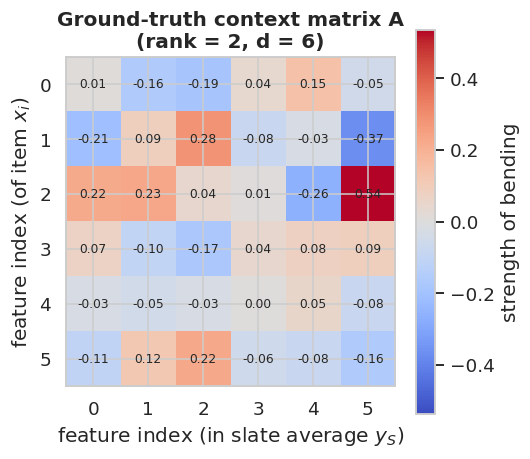

In [3]:
fig, ax = plt.subplots(figsize=(5, 4.5))

vmax = np.abs(A).max()
im = ax.imshow(A, cmap="coolwarm", vmin=-vmax, vmax=vmax)

ax.set_title(f"Ground-truth context matrix A\n(rank = {RANK_A}, d = {D_FEATURES})")
ax.set_xlabel("feature index (in slate average $y_S$)")
ax.set_ylabel("feature index (of item $x_i$)")
ax.set_xticks(range(D_FEATURES))
ax.set_yticks(range(D_FEATURES))

for i in range(D_FEATURES):
    for j in range(D_FEATURES):
        ax.text(j, i, f"{A[i,j]:.2f}", ha="center", va="center", fontsize=8)

plt.colorbar(im, ax=ax, label="strength of bending")
plt.tight_layout()
plt.show()

## Side experiment: why we fix ||A||_F = 1 for every configuration

Before continuing with the main pipeline, a quick demonstration of *why*
we rescale every version of A to the same Frobenius norm, rather than
letting it come out however the random draw produces it.

We build three versions of A — all rank 2, same random directions,
differing only in overall size (||A||_F = 0.2, 1.0, and 5.0) — and look
at two numbers for each:

- **SNR** (context signal / baseline signal): how loud is the context effect?
- **Choice entropy**: how *undecided* are the simulated choices? Low entropy
  means choices are close to deterministic — one item wins almost every time.

The expectation: SNR rises with ||A||_F, as expected. But entropy should
collapse toward zero at the large end — meaning the data stops being
informative even though the "signal" got louder. That collapse is why
bigger is not simply better, and why we need a controlled, comparable
scale rather than whatever a random draw happens to produce.

In [4]:
def build_A_at_norm(d_features, rank_A, frob_norm, seed):
    """Same construction as make_ground_truth, but lets us set the
    Frobenius norm directly so we can compare sizes side by side."""
    rng = np.random.default_rng(seed)
    U = rng.normal(0, 1, size=(d_features, rank_A))
    V = rng.normal(0, 1, size=(d_features, rank_A))
    A = U @ V.T
    A = A / np.linalg.norm(A, ord="fro")   # unit norm first
    A = frob_norm * A                       # then set to the target size
    return A


def quick_snr_and_entropy(theta, A, n_sessions, slate_size, d_features, seed):
    """Simulates one batch of choices and reports SNR + average choice entropy.
    Same simulation logic as the main dataset builder, condensed for this demo."""
    rng = np.random.default_rng(seed)
    X = rng.normal(0, 1, size=(n_sessions, slate_size, d_features))
    y_S = X.mean(axis=1)

    base_term = np.einsum("d,nsd->ns", theta, X)
    ctx_term  = np.einsum("nd,nsd->ns", y_S @ A.T, X)
    snr = ctx_term.var() / base_term.var()

    utilities = base_term + ctx_term
    z = utilities - utilities.max(axis=1, keepdims=True)
    probs = np.exp(z)
    probs /= probs.sum(axis=1, keepdims=True)

    entropy = -(probs * np.log(probs + 1e-12)).sum(axis=1).mean()
    max_entropy = np.log(slate_size)

    return snr, entropy, max_entropy


# --- run the comparison ---
norms_to_try = [0.2, 1.0, 5.0]
results = []

for fn in norms_to_try:
    A_test = build_A_at_norm(D_FEATURES, RANK_A, fn, seed=SEED)
    snr, ent, max_ent = quick_snr_and_entropy(
        theta, A_test, n_sessions=5000, slate_size=5,
        d_features=D_FEATURES, seed=1
    )
    results.append((fn, snr, ent, max_ent))
    print(f"||A||_F = {fn:>4} | SNR = {snr:7.3f} | "
          f"entropy = {ent:.3f} (max possible = {max_ent:.3f}, "
          f"{100*ent/max_ent:.1f}% of max)")

||A||_F =  0.2 | SNR =   0.009 | entropy = 1.302 (max possible = 1.609, 80.9% of max)
||A||_F =  1.0 | SNR =   0.216 | entropy = 1.266 (max possible = 1.609, 78.6% of max)
||A||_F =  5.0 | SNR =   5.396 | entropy = 0.904 (max possible = 1.609, 56.1% of max)


The printed numbers already tell the story in digits. The plot below
puts SNR and entropy on the same picture, so the trade-off is visible
at a glance: as the context effect gets louder, the choices become more
predictable, and past a point that predictability becomes a *problem*
for recovery rather than a help.

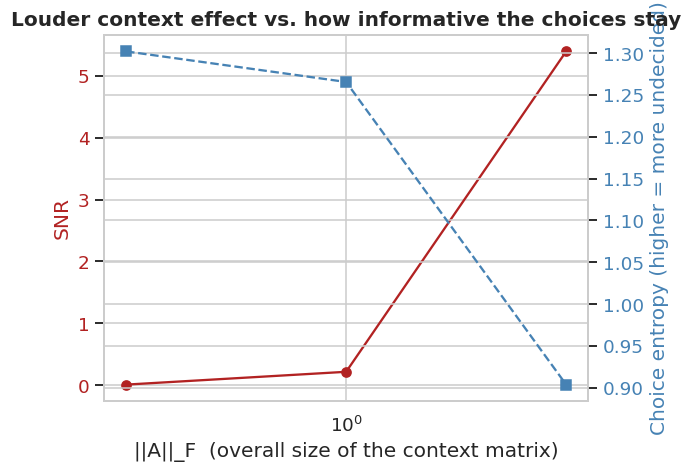

In [5]:
fig, ax1 = plt.subplots(figsize=(6, 4.5))

xs = [r[0] for r in results]
snrs = [r[1] for r in results]
ents = [r[2] for r in results]

ax1.plot(xs, snrs, "o-", color="firebrick", label="SNR (context / baseline)")
ax1.set_xlabel("||A||_F  (overall size of the context matrix)")
ax1.set_ylabel("SNR", color="firebrick")
ax1.tick_params(axis="y", labelcolor="firebrick")
ax1.set_xscale("log")

ax2 = ax1.twinx()
ax2.plot(xs, ents, "s--", color="steelblue", label="Choice entropy")
ax2.set_ylabel("Choice entropy (higher = more undecided)", color="steelblue")
ax2.tick_params(axis="y", labelcolor="steelblue")

plt.title("Louder context effect vs. how informative the choices stay")
fig.tight_layout()
plt.show()

## Part B: Building slates, and watching context "concentrate"

Before we simulate any choices, we need to understand one property of
how slates are built: as slate size grows, the slate-average feature
vector y_S becomes less varied across different slates.

Why this matters: our whole ability to see A depends on y_S varying
from slate to slate. If every slate's y_S looks nearly the same, there
is nothing for A to visibly act differently on — the context signal
gets "washed out" even though A itself hasn't changed.

B1 builds slates and computes y_S. B2 plots how much y_S spreads out,
as a function of slate size.

In [6]:
def draw_slates(n_sessions, slate_size, d_features, seed):
    """
    Draws n_sessions slates, each with slate_size items, each item
    described by d_features independent N(0,1) values.

    Returns:
        X   : shape (n_sessions, slate_size, d_features) — the items
        y_S : shape (n_sessions, d_features) — the per-slate average,
              i.e. what "the page looks like on average"
    """
    rng = np.random.default_rng(seed)
    X = rng.normal(0, 1, size=(n_sessions, slate_size, d_features))
    y_S = X.mean(axis=1)
    return X, y_S


# quick check on one slate size, just to see the shapes
X_check, y_S_check = draw_slates(n_sessions=5, slate_size=5,
                                  d_features=D_FEATURES, seed=1)
print("X shape:", X_check.shape)
print("y_S shape:", y_S_check.shape)
print("\nFirst slate's items:\n", np.round(X_check[0], 2))
print("\nFirst slate's average y_S:\n", np.round(y_S_check[0], 2))

X shape: (5, 5, 6)
y_S shape: (5, 6)

First slate's items:
 [[ 0.35  0.82  0.33 -1.3   0.91  0.45]
 [-0.54  0.58  0.36  0.29  0.03  0.55]
 [-0.74 -0.16 -0.48  0.6   0.04 -0.29]
 [-0.78 -0.26  0.01 -0.28  1.29  1.01]
 [-2.71 -1.89 -0.17 -0.42  0.21  0.22]]

First slate's average y_S:
 [-0.88 -0.18  0.01 -0.22  0.5   0.38]


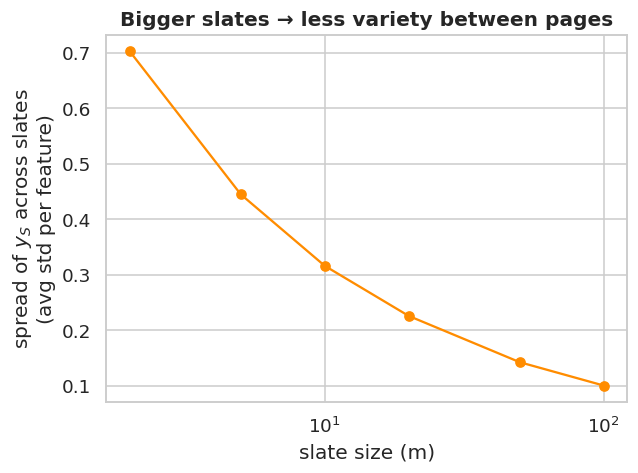

slate_size : spread
    2 : 0.7023
    5 : 0.4446
   10 : 0.3158
   20 : 0.2256
   50 : 0.1422
  100 : 0.1001


In [7]:
slate_sizes = [2, 5, 10, 20, 50, 100]
spreads = []

for m in slate_sizes:
    _, y_S_m = draw_slates(n_sessions=5000, slate_size=m,
                            d_features=D_FEATURES, seed=1)
    spreads.append(y_S_m.std(axis=0).mean())  # avg spread across dims

fig, ax = plt.subplots(figsize=(6, 4.5))
ax.plot(slate_sizes, spreads, "o-", color="darkorange")
ax.set_xlabel("slate size (m)")
ax.set_ylabel("spread of $y_S$ across slates\n(avg std per feature)")
ax.set_title("Bigger slates → less variety between pages")
ax.set_xscale("log")
plt.tight_layout()
plt.show()

print("slate_size : spread")
for m, s in zip(slate_sizes, spreads):
    print(f"  {m:>3} : {s:.4f}")

## Part B — Summary: why slate size matters

**What we did:** built slates of different sizes (m = 2 to 100) and
measured how much the slate-average feature vector, y_S, varies across
different slates of each size.

**What we found:** as slate size (m) grows, y_S varies less and less
across different slates — the spread dropped from 0.70 at m=2 down to
0.10 at m=100, roughly following the 1/√m shape we'd expect from
averaging more random items together.

**Why this matters:** our whole method for detecting A depends on
comparing how the model's preferences shift as the slate composition
changes. If slates are too large, every slate's average starts looking
the same — there's no meaningful variety left between pages for A to
visibly act on, even though A itself hasn't changed. This makes slate
size a genuine identification lever, not a cosmetic setting: choosing
it badly could make context effects invisible no matter how good the
model is.

**Going forward:** we'll use slate_size = 5 as our reference
configuration (matching earlier work), and revisit this as a
deliberate sweep axis later once models are in the picture.





## Part C: Turning slates into choices

So far we've only built pages (slates) — we haven't simulated anyone
actually choosing anything. Part C adds the choice mechanism: given a
slate and our ground-truth (theta, A), compute how attractive each item
is, turn that into a probability distribution over the slate, and
sample one item as "the choice."

C1 builds this step by step. C2 checks whether the resulting choices
are sensibly uncertain — not always obvious, not always a coin flip.

In [8]:
def simulate_choices(theta, A, X, seed):
    """
    Given the ground truth (theta, A) and a batch of slates X,
    simulates one choice per session under the LCL model:

        eff_theta(S) = theta + A @ y_S
        u_i(S)       = eff_theta(S) . x_i
        P(i | S)     = softmax(u(S))
        choice       = sample from P(i | S)

    Returns y_S, utilities, probs, choices — all intermediate values,
    in case we need to inspect or plot any of them later.
    """
    rng = np.random.default_rng(seed)

    y_S = X.mean(axis=1)
    eff_theta = theta[None, :] + y_S @ A.T
    utilities = np.einsum("nd,nsd->ns", eff_theta, X)

    z = utilities - utilities.max(axis=1, keepdims=True)
    probs = np.exp(z)
    probs /= probs.sum(axis=1, keepdims=True)

    cdf = probs.cumsum(axis=1)
    draws = rng.random((X.shape[0], 1))
    choices = (draws > cdf).sum(axis=1)
    choices = np.clip(choices, 0, X.shape[1] - 1)

    return y_S, utilities, probs, choices


# quick check on the same 5-slate toy example
y_S_c, util_c, probs_c, choices_c = simulate_choices(theta, A, X_check, seed=1)
print("Probabilities for session 0:", np.round(probs_c[0], 3), "sum:", probs_c[0].sum())
print("Chosen items across all 5 sessions:", choices_c)

Probabilities for session 0: [0.158 0.186 0.276 0.141 0.239] sum: 1.0
Chosen items across all 5 sessions: [2 4 0 4 0]


## Part C2: Are the simulated choices actually informative?

Now that we can simulate choices, a real question worth checking: are
they too easy (one item almost always wins, entropy near 0) or too hard
(every item is basically a coin flip, entropy near max)?

Either extreme is a problem. Too easy, and there's no meaningful
variation for the probe to detect. Too hard, and there's so much
randomness that any model — even the oracle — would struggle to see a
pattern. We want most sessions to land somewhere in between: genuinely
uncertain, but not pure noise.

Max possible entropy (pure coin-flip over 5 items): 1.609
Mean entropy across 5000 sessions: 1.265  (78.6% of max)
Min entropy (most 'obvious' session): 0.075
Max entropy (most 'undecided' session): 1.605


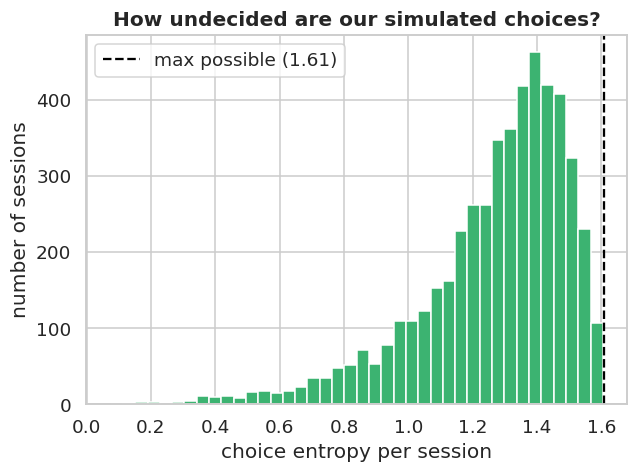

In [9]:
N_SESSIONS_DEMO = 5000
SLATE_SIZE = 5

X_demo, y_S_demo = draw_slates(N_SESSIONS_DEMO, SLATE_SIZE, D_FEATURES, seed=42)
_, util_demo, probs_demo, choices_demo = simulate_choices(theta, A, X_demo, seed=42)

entropy = -(probs_demo * np.log(probs_demo + 1e-12)).sum(axis=1)
max_entropy = np.log(SLATE_SIZE)

print(f"Max possible entropy (pure coin-flip over {SLATE_SIZE} items): {max_entropy:.3f}")
print(f"Mean entropy across {N_SESSIONS_DEMO} sessions: {entropy.mean():.3f}"
      f"  ({100*entropy.mean()/max_entropy:.1f}% of max)")
print(f"Min entropy (most 'obvious' session): {entropy.min():.3f}")
print(f"Max entropy (most 'undecided' session): {entropy.max():.3f}")

fig, ax = plt.subplots(figsize=(6, 4.5))
ax.hist(entropy, bins=40, color="mediumseagreen", edgecolor="white")
ax.axvline(max_entropy, color="black", linestyle="--", label=f"max possible ({max_entropy:.2f})")
ax.set_xlabel("choice entropy per session")
ax.set_ylabel("number of sessions")
ax.set_title("How undecided are our simulated choices?")
ax.legend()
plt.tight_layout()
plt.show()

## Part C — Summary

We now have the full simulation pipeline: slate → slate-average y_S →
bent preference (theta + A y_S) → utilities → softmax probabilities →
one sampled choice per session.

Entropy diagnostics confirmed our reference configuration (d=6, rank(A)=2,
||A||_F=1.0, slate_size=5) sits in a useful middle zone: choices are
mostly undecided (mean entropy 78.6% of max) but with a real tail of
decisive sessions (min entropy 0.075) — neither pure noise nor
near-deterministic. Good conditions for the probe to have something to
detect.




## Part D: Assembling the three data splits

Now we combine slate-building (Part B) and choice simulation (Part C)
into the actual dataset we'll train models on: a training split, an
in-distribution evaluation split, and a deliberately unusual
("shifted") evaluation split — all generated from the SAME ground
truth (theta, A), so any difference between them is purely about slate
composition, not a different underlying world.

### D1: Train and in-distribution eval — from ONE shared draw

Train and eval_in should be identically distributed — same slate
construction rule, same everything except which specific sessions
landed in which bucket. The way to guarantee that, rather than hope
for it, is to draw one big batch of slates and split it by index,
rather than calling the slate generator twice with different seeds.
Two separate calls could drift apart in distribution by accident;
one call sliced in two cannot.

In [10]:
N_TRAIN = 20000
N_EVAL  = 5000
SLATE_SIZE = 5

X_all, _ = draw_slates(N_TRAIN + N_EVAL, SLATE_SIZE, D_FEATURES, seed=SEED)
X_train, X_eval_in = X_all[:N_TRAIN], X_all[N_TRAIN:]

print("X_train shape:  ", X_train.shape)
print("X_eval_in shape:", X_eval_in.shape)

X_train shape:   (20000, 5, 6)
X_eval_in shape: (5000, 5, 6)


### D2: The shifted split — unusual compositions of ordinary items

Every individual item here is still drawn from the same N(0,1)
distribution as train — nothing about the items themselves is exotic.
What's unusual is the COMBINATION: we over-generate a large pool of
candidate slates, then keep only the ones whose slate-average y_S is
farthest from the origin — the compositions that plain random sampling
would rarely produce on its own.

In [11]:
N_SHIFT = 5000
OVERSAMPLE = 20   # generate 20x candidates, keep the most extreme

def make_shifted_slates(n_shift, slate_size, d_features, seed, oversample=20):
    rng = np.random.default_rng(seed)
    pool = rng.normal(0, 1, size=(n_shift * oversample, slate_size, d_features))
    norms = np.linalg.norm(pool.mean(axis=1), axis=1)
    keep = np.argsort(norms)[-n_shift:]   # the most extreme y_S norms
    return pool[keep]

X_shift = make_shifted_slates(N_SHIFT, SLATE_SIZE, D_FEATURES, seed=SEED, oversample=OVERSAMPLE)
print("X_shift shape:", X_shift.shape)

X_shift shape: (5000, 5, 6)


### D3: Simulate choices on all three splits, and package everything

Same simulate_choices function from Part C, applied identically to
train, eval_in, and eval_shift — same ground truth (theta, A) every
time, only the slates differ.

In [12]:
def build_split(X, theta, A, seed, name):
    y_S, utilities, probs, choices = simulate_choices(theta, A, X, seed)
    print(f"{name:<12} n={X.shape[0]:>6}  slate_size={X.shape[1]}")
    return dict(X=X, y_S=y_S, utilities=utilities, probs=probs, choices=choices)

splits = {
    "train":      build_split(X_train,   theta, A, seed=1, name="train"),
    "eval_in":    build_split(X_eval_in, theta, A, seed=2, name="eval_in"),
    "eval_shift": build_split(X_shift,   theta, A, seed=3, name="eval_shift"),
}

train        n= 20000  slate_size=5
eval_in      n=  5000  slate_size=5
eval_shift   n=  5000  slate_size=5


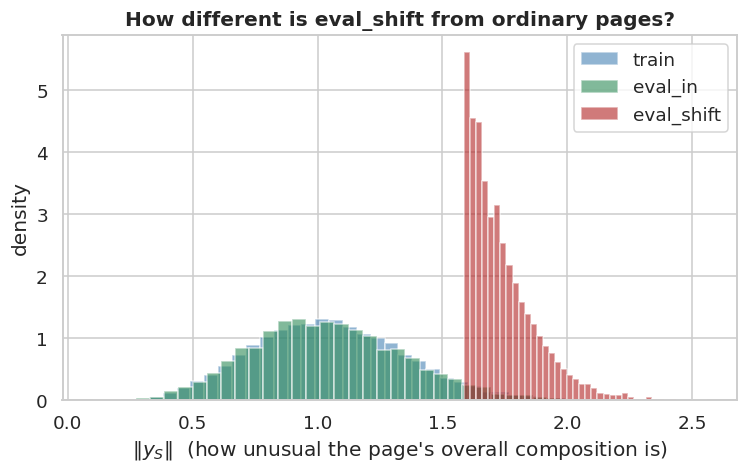

train median ||y_S||:      1.038
eval_in median ||y_S||:    1.026
eval_shift median ||y_S||: 1.703

train's 99th percentile ||y_S||: 1.823
fraction of eval_shift beyond that: 0.219


In [13]:
norms_train = np.linalg.norm(splits["train"]["y_S"], axis=1)
norms_eval_in = np.linalg.norm(splits["eval_in"]["y_S"], axis=1)
norms_eval_shift = np.linalg.norm(splits["eval_shift"]["y_S"], axis=1)

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.hist(norms_train, bins=40, alpha=0.6, label="train", color="steelblue", density=True)
ax.hist(norms_eval_in, bins=40, alpha=0.6, label="eval_in", color="seagreen", density=True)
ax.hist(norms_eval_shift, bins=40, alpha=0.6, label="eval_shift", color="firebrick", density=True)

ax.set_xlabel("$\\|y_S\\|$  (how unusual the page's overall composition is)")
ax.set_ylabel("density")
ax.set_title("How different is eval_shift from ordinary pages?")
ax.legend()
plt.tight_layout()
plt.show()

train_p99 = np.percentile(norms_train, 99)
frac_beyond = (norms_eval_shift > train_p99).mean()

print(f"train median ||y_S||:      {np.median(norms_train):.3f}")
print(f"eval_in median ||y_S||:    {np.median(norms_eval_in):.3f}")
print(f"eval_shift median ||y_S||: {np.median(norms_eval_shift):.3f}")
print(f"\ntrain's 99th percentile ||y_S||: {train_p99:.3f}")
print(f"fraction of eval_shift beyond that: {frac_beyond:.3f}")

### Why eval_in and eval_shift are both necessary

eval_in and train share one distribution — the plot above should show
their histograms overlapping almost exactly. eval_in exists to answer
a narrow question: does the model generalize to unseen pages that look
like the ones it trained on? Good performance here is necessary, but
not enough, to trust that a model learned the real mechanism.

eval_shift is deliberately built from the rare tail of what ordinary
sampling could produce — the histogram should show it sitting well to
the right of train and eval_in, not overlapping them.

The reason we need both: a model could score just as well as another
on eval_in by memorizing patterns specific to typical pages, without
ever learning how preferences actually bend with context. Since
train and eval_in look alike, that shortcut would go undetected.
eval_shift is where it gets caught — a model that only memorized
should degrade there, while a model that learned the true rule
theta + A @ y_S should hold up, since that formula is just as valid on
an unusual page as an ordinary one.

So the pairing turns "did the model recover A" from an abstract
correlation number into a concrete, checkable claim: does its
predictive quality survive on pages unlike anything it trained on.

### Checking: did selecting for extreme y_S make eval_shift "too easy"?

eval_shift has higher ||y_S|| than train by construction. Bigger y_S
means a bigger context bend, which should make context effects more
visible — but if pushed too far, it can also make choices nearly
deterministic (as we saw earlier when ||A||_F got too large), which
would actually hurt rather than help.

We check this the same way we checked the base dataset in Part C2:
compare the entropy distributions of train vs. eval_shift directly.

train:      mean entropy = 1.274  (79.1% of max)
eval_shift: mean entropy = 1.227  (76.2% of max)


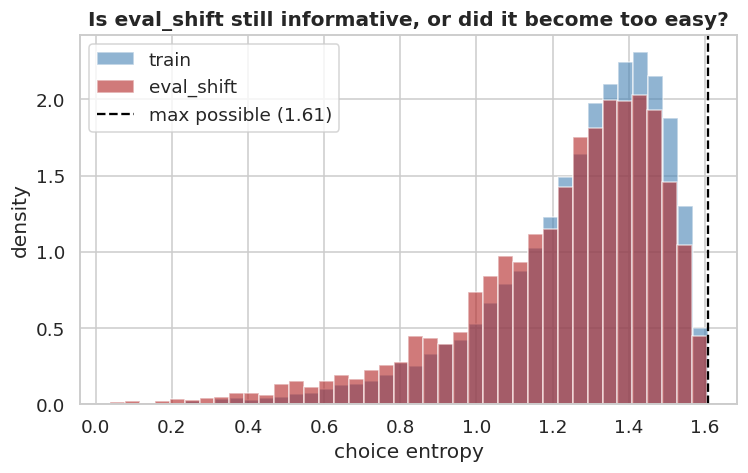

In [14]:
def compute_entropy(probs):
    return -(probs * np.log(probs + 1e-12)).sum(axis=1)

ent_train = compute_entropy(splits["train"]["probs"])
ent_shift = compute_entropy(splits["eval_shift"]["probs"])
max_ent = np.log(SLATE_SIZE)

print(f"train:      mean entropy = {ent_train.mean():.3f}  ({100*ent_train.mean()/max_ent:.1f}% of max)")
print(f"eval_shift: mean entropy = {ent_shift.mean():.3f}  ({100*ent_shift.mean()/max_ent:.1f}% of max)")

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.hist(ent_train, bins=40, alpha=0.6, label="train", color="steelblue", density=True)
ax.hist(ent_shift, bins=40, alpha=0.6, label="eval_shift", color="firebrick", density=True)
ax.axvline(max_ent, color="black", linestyle="--", label=f"max possible ({max_ent:.2f})")
ax.set_xlabel("choice entropy")
ax.set_ylabel("density")
ax.set_title("Is eval_shift still informative, or did it become too easy?")
ax.legend()
plt.tight_layout()
plt.show()

## Part E: The probe estimator — recovering A from any model's scores

So far everything has been about building data, not measuring a model.
Part E builds the *instrument* we'll use to ask: "given a trained
model, how much of the true A did it actually learn?"

### How this differs from our earlier evaluation metrics (Metric A / Metric C)

Earlier work (Metric A, Metric C) asked a **behavioral** question: does
the model act context-sensitively? Concretely, swap one item for
another and watch how the log-ratio of choice probabilities shifts.
Metric C in particular was designed to survive softmax saturation,
which had made Metric A's raw slope readings unreliable (the same true
effect could read as 0.51 or 2.65 depending purely on which probability
region was probed).

What we're building now asks a **structural** question instead: can we
reconstruct the actual matrix A, entry by entry, and compare it
directly to the ground truth? This is strictly harder, and it matters
because of a gap we already found on CDM — direct weight readout said
recovery was ~0, while Metric C (behavioral) said 0.737. That gap is
real, but it leaves something unresolved: does a high Metric C score
mean the model found the *right* mechanism, or just *some* mechanism
that happens to produce similar swap behavior? Full matrix
reconstruction is what lets us answer that more precisely.

### The core idea

Place two fixed probe items (a, b) into many different slates, and
watch how the model's score gap between them shifts as the surrounding
filler items change. Under LCL, letting $\delta = x_a - x_b$:

$$\Delta(S) = \theta^\top \delta \;+\; y_S^\top (A^\top \delta)$$

This is ordinary linear regression: regressing the score gap on $y_S$
recovers one "shadow" of A — a single projection, seen from the angle
of that one probe pair. To reconstruct the *full* matrix, we repeat
this with several different probe pairs, each viewed from a different
angle, and solve a joint linear system for A itself.

We'll build this in three small steps:
  - **E1** — construct one probe pair and the slates around it *(done — confirmed the probe pair stays fixed across trials while fillers vary, which is exactly the property this method depends on)*
  - **E2** — regress score gap on $y_S$, for one probe pair
  - **E3** — repeat across several probe pairs and solve for $\hat A$

In [15]:
def make_one_probe_pair(d_features, seed):
    """
    A single probe pair (a, b): two fixed items we'll reuse across many
    slates. Drawn from the same N(0,1) distribution as ordinary items,
    so the model is never asked to score something out-of-distribution.
    """
    rng = np.random.default_rng(seed)
    x_a = rng.normal(0, 1, size=d_features)
    x_b = rng.normal(0, 1, size=d_features)
    return x_a, x_b


def build_slates_around_pair(x_a, x_b, n_trials, slate_size, d_features, seed):
    """
    n_trials slates, each with the SAME probe pair at positions 0 and 1,
    and fresh random filler items everywhere else. Since a and b never
    change, any change in the score gap across trials must come from
    the fillers -- which is exactly what moves y_S.
    """
    rng = np.random.default_rng(seed)
    n_fill = slate_size - 2
    fillers = rng.normal(0, 1, size=(n_trials, n_fill, d_features))
    a_block = np.broadcast_to(x_a, (n_trials, 1, d_features))
    b_block = np.broadcast_to(x_b, (n_trials, 1, d_features))
    return np.concatenate([a_block, b_block, fillers], axis=1)


# --- quick check with one probe pair ---
x_a, x_b = make_one_probe_pair(D_FEATURES, seed=99)
X_probe = build_slates_around_pair(x_a, x_b, n_trials=5, slate_size=SLATE_SIZE,
                                    d_features=D_FEATURES, seed=1)

print("Probe item a:", np.round(x_a, 3))
print("Probe item b:", np.round(x_b, 3))
print("\nOne example slate (a and b should be rows 0 and 1, identical across trials):")
print(np.round(X_probe[0], 3))
print("\nAnother trial's slate (rows 0,1 same as above, rest different):")
print(np.round(X_probe[1], 3))

Probe item a: [ 0.082 -0.464  0.051  0.686 -1.757  1.684]
Probe item b: [-0.458 -0.596 -1.047  0.932  0.675  1.244]

One example slate (a and b should be rows 0 and 1, identical across trials):
[[ 0.082 -0.464  0.051  0.686 -1.757  1.684]
 [-0.458 -0.596 -1.047  0.932  0.675  1.244]
 [ 0.346  0.822  0.33  -1.303  0.905  0.446]
 [-0.537  0.581  0.365  0.294  0.028  0.547]
 [-0.736 -0.163 -0.482  0.599  0.04  -0.292]]

Another trial's slate (rows 0,1 same as above, rest different):
[[ 0.082 -0.464  0.051  0.686 -1.757  1.684]
 [-0.458 -0.596 -1.047  0.932  0.675  1.244]
 [-0.782 -0.257  0.008 -0.276  1.294  1.007]
 [-2.711 -1.889 -0.175 -0.422  0.214  0.217]
 [ 2.118 -1.112 -0.378  2.043  0.647  0.663]]


### E2: Regress the score gap on y_S — for ONE probe pair

Now we scale up from 5 toy trials to a proper number, so the
regression actually has enough data to fit anything meaningful.

For this step we use the TRUE scoring function (the generator's own
formula) rather than a trained model — same reasoning as Part C's
validation: check the estimator's arithmetic works perfectly under
zero-noise, known-answer conditions, before ever trusting it on
something noisier.

If this works, the regression's slope should come out equal to
$g = A^\top \delta$ almost exactly — computable directly and independently,
giving us a known answer to check against.

In [16]:
def score_fn_true(X):
    """The generator's own scoring rule, exposed as score_fn(X) -> scores.
    Same interface any trained model will eventually plug into."""
    y_S = X.mean(axis=1)
    eff_theta = theta[None, :] + y_S @ A.T
    return np.einsum("nd,nsd->ns", eff_theta, X)


# --- one probe pair, many trials this time ---
N_TRIALS = 2000

x_a, x_b = make_one_probe_pair(D_FEATURES, seed=99)
X_probe = build_slates_around_pair(x_a, x_b, n_trials=N_TRIALS, slate_size=SLATE_SIZE,
                                    d_features=D_FEATURES, seed=1)

y_S_probe = X_probe.mean(axis=1)
scores = score_fn_true(X_probe)
delta_scores = scores[:, 0] - scores[:, 1]   # score(a) - score(b), per trial

# --- regression: [1, y_S] -> delta_scores ---
design = np.concatenate([np.ones((N_TRIALS, 1)), y_S_probe], axis=1)
coef, *_ = np.linalg.lstsq(design, delta_scores, rcond=None)
intercept_hat = coef[0]
slope_hat = coef[1:]           # this should equal A^T @ delta

# --- known answer, computed directly, to check against ---
delta = x_a - x_b
intercept_true = theta @ delta
slope_true = A.T @ delta

print("intercept: fitted =", round(intercept_hat, 4), " true =", round(intercept_true, 4))
print("\nslope (g = A^T delta):")
print("  fitted:", np.round(slope_hat, 4))
print("  true:  ", np.round(slope_true, 4))
print("\nmax abs difference:", np.max(np.abs(slope_hat - slope_true)))

# R^2, to check the fit quality
pred = design @ coef
ss_res = ((delta_scores - pred) ** 2).sum()
ss_tot = ((delta_scores - delta_scores.mean()) ** 2).sum()
r2 = 1 - ss_res / ss_tot
print("\nR^2 of the regression:", round(r2, 6))

intercept: fitted = -0.7319  true = -0.7319

slope (g = A^T delta):
  fitted: [ 0.2269  0.3697  0.1914 -0.0264 -0.3923  0.6118]
  true:   [ 0.2269  0.3697  0.1914 -0.0264 -0.3923  0.6118]

max abs difference: 3.608224830031759e-16

R^2 of the regression: 1.0


### E3: Repeat across several probe pairs, and solve for the full A

One probe pair gives one projection of A — a single "shadow," as seen
from one angle. To reconstruct the full 6x6 matrix, we need several
probe pairs, each giving a shadow from a different angle, then solve
for A jointly.

Concretely: for K probe pairs, each with direction $\delta_k = x_a^{(k)} - x_b^{(k)}$,
we get K slope vectors $g_k = A^\top \delta_k$. Stacking these into
matrices $D$ (rows $\delta_k$) and $G$ (rows $g_k$):

$$G = D A$$

and we solve for A via least squares. From the earlier analytic check
(back when we validated this same math with K=6, 12, 24), we know
K = 2d gives good conditioning — stable inversion, not overly sensitive
to noise. With d=6, that means K=12 probe pairs.

In [17]:
def estimate_A_from_scores(score_fn, K, n_trials, slate_size, d_features, seed):
    """
    Runs the E1+E2 procedure across K probe pairs, then solves for the
    full matrix A. score_fn is model-agnostic -- it only ever sees
    slates in, scores out.
    """
    rng = np.random.default_rng(seed)

    D_rows = []
    G_rows = []

    for k in range(K):
        x_a_k = rng.normal(0, 1, size=d_features)
        x_b_k = rng.normal(0, 1, size=d_features)
        delta_k = x_a_k - x_b_k

        X_k = build_slates_around_pair(x_a_k, x_b_k, n_trials, slate_size,
                                        d_features, seed=rng.integers(1e9))
        y_S_k = X_k.mean(axis=1)
        scores_k = score_fn(X_k)
        delta_scores_k = scores_k[:, 0] - scores_k[:, 1]

        design = np.concatenate([np.ones((n_trials, 1)), y_S_k], axis=1)
        coef, *_ = np.linalg.lstsq(design, delta_scores_k, rcond=None)

        D_rows.append(delta_k)
        G_rows.append(coef[1:])

    D_mat = np.array(D_rows)   # (K, d)
    G_mat = np.array(G_rows)   # (K, d)

    A_hat, *_ = np.linalg.lstsq(D_mat, G_mat, rcond=None)
    return A_hat, D_mat, G_mat


K = 2 * D_FEATURES   # = 12
A_hat, D_mat, G_mat = estimate_A_from_scores(
    score_fn_true, K=K, n_trials=2000, slate_size=SLATE_SIZE,
    d_features=D_FEATURES, seed=7
)

print("Recovered A_hat:")
print(np.round(A_hat, 4))
print("\nTrue A:")
print(np.round(A, 4))
print("\nMax abs difference:", np.max(np.abs(A_hat - A)))
print("Condition number of D:", round(np.linalg.cond(D_mat), 2))

Recovered A_hat:
[[ 0.0098 -0.1631 -0.1862  0.0414  0.1453 -0.0538]
 [-0.2055  0.0865  0.2844 -0.0761 -0.0265 -0.3656]
 [ 0.2204  0.2291  0.0447  0.0052 -0.2632  0.5361]
 [ 0.0672 -0.1038 -0.1749  0.0428  0.0771  0.0857]
 [-0.0288 -0.0488 -0.0263  0.0038  0.0515 -0.0785]
 [-0.1062  0.1156  0.2239 -0.0561 -0.0779 -0.1571]]

True A:
[[ 0.0098 -0.1631 -0.1862  0.0414  0.1453 -0.0538]
 [-0.2055  0.0865  0.2844 -0.0761 -0.0265 -0.3656]
 [ 0.2204  0.2291  0.0447  0.0052 -0.2632  0.5361]
 [ 0.0672 -0.1038 -0.1749  0.0428  0.0771  0.0857]
 [-0.0288 -0.0488 -0.0263  0.0038  0.0515 -0.0785]
 [-0.1062  0.1156  0.2239 -0.0561 -0.0779 -0.1571]]

Max abs difference: 8.326672684688674e-16
Condition number of D: 2.98


### Part E — Summary

We built the probe estimator in three steps:
  - E1: confirmed slates around a probe pair correctly hold (a, b)
    fixed while varying fillers
  - E2: confirmed a single probe pair's regression exactly recovers
    its "shadow" of A (one projection, g = A^T delta)
  - E3: confirmed stacking K=12 probe pairs and solving the joint
    system G = DA exactly recovers the FULL matrix A

All three passed at floating-point precision (differences ~1e-16),
confirming the estimator's arithmetic is correct.

**Important scope check:** this only validates the *math*. We fed in
the generator's own scoring function — zero noise, and a model that
literally *is* A. It does not yet tell us whether this same procedure
works on a model that stores context through some other mechanism
entirely (a neural net's weights, an attention pattern). That is a
separate, harder question, and it's the next real test — not a
formality, since this is exactly where CDM's direct-weight-readout
approach silently failed before (reporting ~0 when the true answer
was 0.737).

Hi, this is a test from Surya